# Predict the attack type

This is the second stage of the IDS. It uses only attack rows and predicts one of the CIC-IDS2017 attack types.

In [1]:
from pathlib import Path
import json
import time

import joblib
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    ConfusionMatrixDisplay, accuracy_score, classification_report,
    f1_score, precision_score, recall_score,
)

In [2]:
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent

TRAIN_FILE = PROJECT_ROOT / 'dataset/processed/train.parquet'
TEST_FILE = PROJECT_ROOT / 'dataset/processed/test.parquet'
FEATURE_FILE = PROJECT_ROOT / 'artifacts/feature_selection/selected_features.json'
OUTPUT_FOLDER = PROJECT_ROOT / 'artifacts/attack_type_model'
RANDOM_STATE = 42

## Load attack rows

`BENIGN` is removed because it is not an attack type. The selected features from the previous stage are reused.

In [3]:
feature_report = json.loads(FEATURE_FILE.read_text(encoding='utf-8'))
features = feature_report['selected_features']
columns = features + ['attack_label']

train = pd.read_parquet(TRAIN_FILE, columns=columns)
test = pd.read_parquet(TEST_FILE, columns=columns)
train = train[train['attack_label'] != 'BENIGN']
test = test[test['attack_label'] != 'BENIGN']

x_train, y_train = train[features], train['attack_label']
x_test, y_test = test[features], test['attack_label']

print(f'Training attacks: {len(train):,}')
print(f'Testing attacks:  {len(test):,}')
y_train.value_counts().to_frame('training rows')

Training attacks: 340,593
Testing attacks:  85,148


,training rows
attack_label,
DoS Hulk,138165
DDoS,102382
PortScan,72508
DoS GoldenEye,8318
FTP - Patator,4802
DoS slowloris,4284
DoS Slowhttptest,4242
SSH - Patator,2584
Bot,1564


## Train Random Forest

Balanced class weights reduce the effect of the large difference between common and rare attacks.

In [4]:
model = RandomForestClassifier(
    n_estimators=150,
    max_depth=25,
    class_weight='balanced_subsample',
    n_jobs=-1,
    random_state=RANDOM_STATE,
)

start = time.perf_counter()
model.fit(x_train, y_train)
training_seconds = time.perf_counter() - start
print(f'Training completed in {training_seconds:.1f} seconds')

Training completed in 17.2 seconds


## Evaluate every attack class

Macro scores give every attack type equal importance, including rare classes.

In [5]:
start = time.perf_counter()
predictions = model.predict(x_test)
prediction_seconds = time.perf_counter() - start

metrics = {
    'accuracy': accuracy_score(y_test, predictions),
    'precision_macro': precision_score(y_test, predictions, average='macro', zero_division=0),
    'recall_macro': recall_score(y_test, predictions, average='macro', zero_division=0),
    'f1_macro': f1_score(y_test, predictions, average='macro', zero_division=0),
    'f1_weighted': f1_score(y_test, predictions, average='weighted', zero_division=0),
    'training_seconds': training_seconds,
    'prediction_seconds': prediction_seconds,
}
per_class = classification_report(
    y_test, predictions, labels=model.classes_, output_dict=True, zero_division=0
)
display(pd.Series(metrics).to_frame('value').round(4))
display(pd.DataFrame(per_class).transpose().round(4))

,value
accuracy,0.9966
precision_macro,0.8725
recall_macro,0.8956
f1_macro,0.8777
f1_weighted,0.9969
training_seconds,17.2334
prediction_seconds,0.4615


,precision,recall,f1-score,support
Bot,1.0000,1.0000,1.0000,384.0000
DDoS,0.9999,0.9998,0.9998,25632.0000
DoS GoldenEye,0.9929,0.9949,0.9939,1968.0000
DoS Hulk,0.9993,0.9975,0.9984,34681.0000
DoS Slowhttptest,0.9959,0.9939,0.9949,986.0000
DoS slowloris,0.9937,0.9973,0.9955,1101.0000
FTP - Patator,1.0000,1.0000,1.0000,1129.0000
Heartbleed,1.0000,1.0000,1.0000,3.0000
Infiltration,1.0000,1.0000,1.0000,6.0000
PortScan,0.9996,0.9996,0.9996,18186.0000


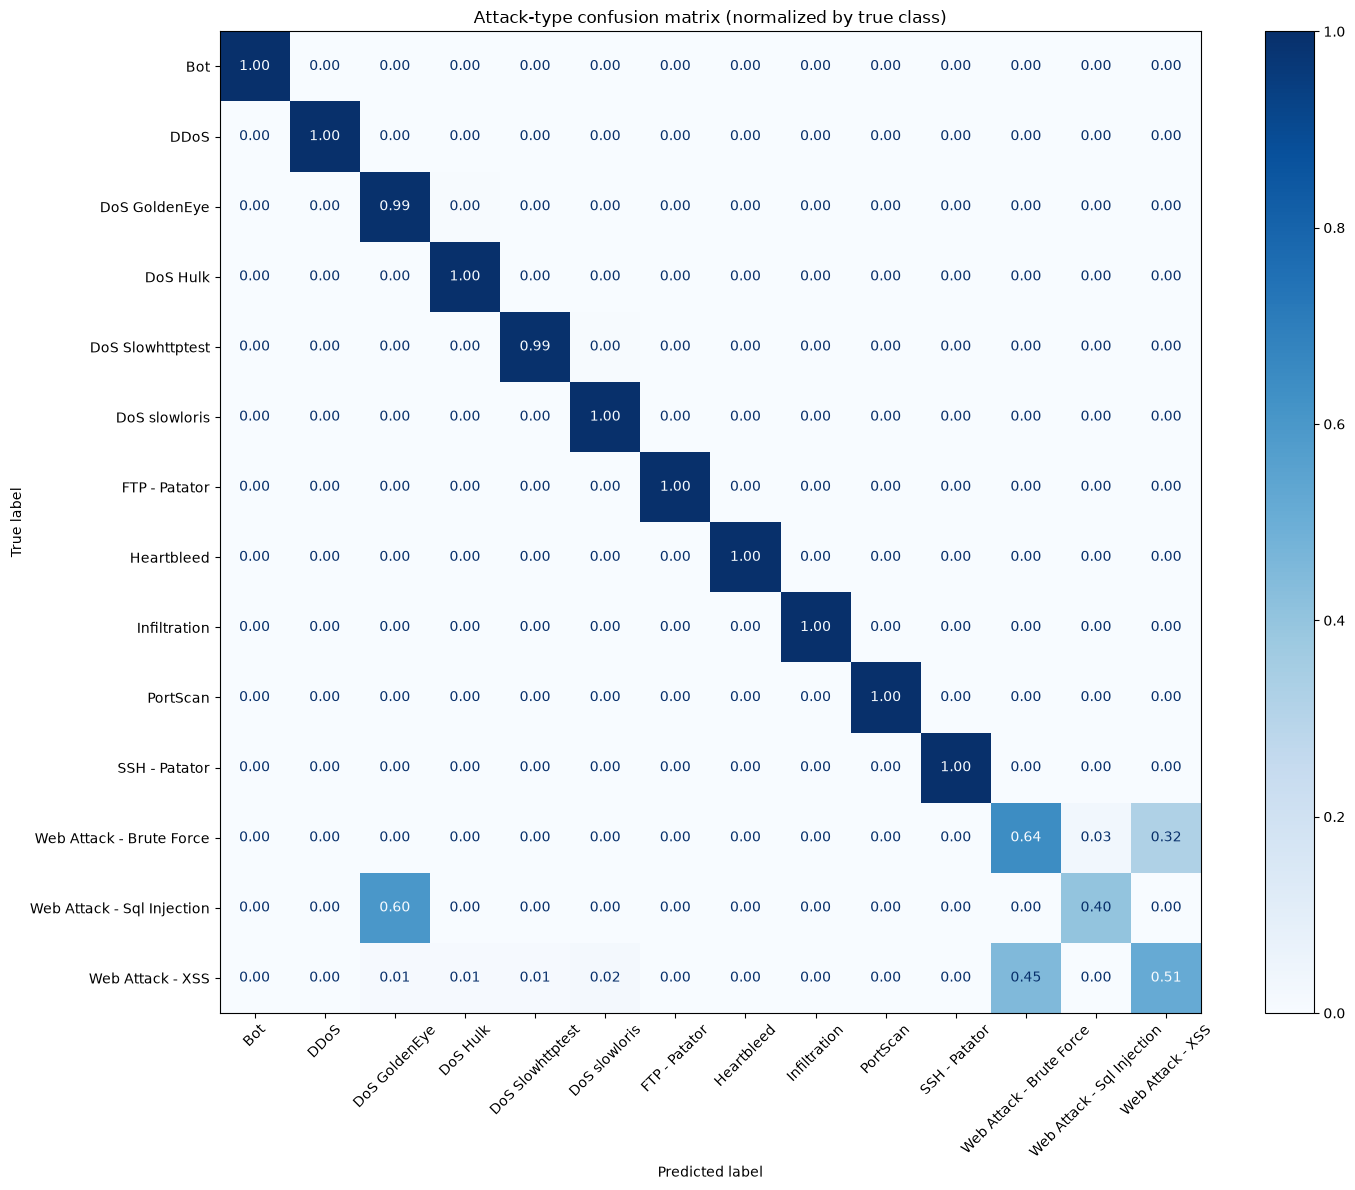

In [6]:
figure, axis = plt.subplots(figsize=(15, 12))
ConfusionMatrixDisplay.from_predictions(
    y_test, predictions, labels=model.classes_, display_labels=model.classes_,
    normalize='true', values_format='.2f', cmap='Blues',
    xticks_rotation=45, ax=axis,
)
axis.set_title('Attack-type confusion matrix (normalized by true class)')
plt.tight_layout()
plt.show()

## Save the trained model and results

In [7]:
OUTPUT_FOLDER.mkdir(parents=True, exist_ok=True)
joblib.dump(model, OUTPUT_FOLDER / 'random_forest_attack_type.joblib')
figure.savefig(OUTPUT_FOLDER / 'confusion_matrix.png', dpi=150)
pd.DataFrame(per_class).transpose().to_csv(OUTPUT_FOLDER / 'per_class_metrics.csv')

report = {
    'model': 'Random Forest',
    'classes': model.classes_.tolist(),
    'selected_features': features,
    'training_rows': len(x_train),
    'testing_rows': len(x_test),
    'metrics': metrics,
    'per_class_metrics': per_class,
}
(OUTPUT_FOLDER / 'report.json').write_text(
    json.dumps(report, indent=2), encoding='utf-8'
)
print(f'Saved results in {OUTPUT_FOLDER}')

Saved results in d:\Learn\Master\SBU\Network Security\Final Project\CICIDS2017-ML-IDS\artifacts\attack_type_model
